In [1]:
import pickle, os

# run this notebook with conda env "compatible_with_sciencecloud_202608"
# needs exact same versions of scikit-learn etc. as the environment used to train the model


version = 'linguistics'
version = 'linguistics_and_demographics'
version = 'demographics_only'

target = 'language'
#target = 'executive_function'
#target = 'speed'
#target = 'memory'

# linguistics only
if version == 'linguistics':
    trained_model_basedir = "/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw34/20260821_0924_9087_svr_rbf_test_on_cohortB"
    if target == 'language':
        trained_model_dir = os.path.join(trained_model_basedir, "20260821_0936_svr_rbf_svr_all_individual_linguistic_only_log_data_all_individual_composite_language_gamma0.001-epsilon0.321471781635738-C3.359818286283781_jyxy")
    elif target == 'executive_function':
        trained_model_dir = os.path.join(trained_model_basedir, "20260821_0939_svr_rbf_svr_all_individual_linguistic_only_log_data_all_individual_composite_executive_function_gamma0.001-epsilon0.321471781635738-C3.359818286283781_vwha")
    elif target == 'speed':
        trained_model_dir = os.path.join(trained_model_basedir, "20260821_0938_svr_rbf_svr_all_individual_linguistic_only_log_data_all_individual_composite_speed_gamma0.001-epsilon0.321471781635738-C3.359818286283781_cysc")
    elif target == 'memory':
        trained_model_dir = os.path.join(trained_model_basedir, "20260821_0937_svr_rbf_svr_all_individual_linguistic_only_log_data_all_individual_composite_memory_gamma0.001-epsilon0.321471781635738-C3.359818286283781_kpok")
    else:
        raise ValueError(f"Unknown target: {target}")
    model = pickle.loads(open(f"{trained_model_dir}/model_split0.pkl", "rb").read())
    outlier_removal = pickle.loads(open(f"{trained_model_dir}/outlier_removal_split0.pkl", "rb").read())
    feature_standardizer = pickle.loads(open(f"{trained_model_dir}/feature_standardizer_split0.pkl", "rb").read())


# linguistics & demographics
elif version == 'linguistics_and_demographics':
    trained_model_basedir = "/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw36/20260831_1445_3c78_svr_rbf_test_on_cohortB_linguistic_and_demographics"
    if target == 'language':
        trained_model_dir = os.path.join(trained_model_basedir, "20260831_1604_svr_rbf_svr_all_individual_linguistic_and_demographics_log_data_all_individual_composite_language_gamma0.001-epsilon0.321471781635738-C3.359818286283781_gofm")
    elif target == 'executive_function':
        trained_model_dir = os.path.join(trained_model_basedir, "20260831_1613_svr_rbf_svr_all_individual_linguistic_and_demographics_log_data_all_individual_composite_executive_function_gamma0.001-epsilon0.321471781635738-C3.359818286283781_tphd")
    elif target == 'speed':
        trained_model_dir = os.path.join(trained_model_basedir, "20260831_1612_svr_rbf_svr_all_individual_linguistic_and_demographics_log_data_all_individual_composite_speed_gamma0.001-epsilon0.321471781635738-C3.359818286283781_kbaz")
    elif target == 'memory':
        trained_model_dir = os.path.join(trained_model_basedir, "20260831_1611_svr_rbf_svr_all_individual_linguistic_and_demographics_log_data_all_individual_composite_memory_gamma0.001-epsilon0.321471781635738-C3.359818286283781_kcpr")
    else:
        raise ValueError(f"Unknown target: {target}")
    model = pickle.loads(open(f"{trained_model_dir}/model_split0.pkl", "rb").read())
    outlier_removal = pickle.loads(open(f"{trained_model_dir}/outlier_removal_split0.pkl", "rb").read())
    feature_standardizer = pickle.loads(open(f"{trained_model_dir}/feature_standardizer_split0.pkl", "rb").read())

elif version == 'demographics_only':
    trained_model_basedir = "/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw37/20260908_1209_eb89_svr_rbf_wave1_cohortA_demographics_only"
    if target == 'language':
        trained_model_dir = os.path.join(trained_model_basedir, "20260908_1209_svr_rbf_svr_all_individual_demographics_only_log_data_all_individual_composite_language_gamma0.001-epsilon0.321471781635738-C3.359818286283781_cjpy")
    elif target == 'executive_function':
        trained_model_dir = os.path.join(trained_model_basedir, "20260908_1217_svr_rbf_svr_all_individual_demographics_only_log_data_all_individual_composite_executive_function_gamma0.001-epsilon0.321471781635738-C3.359818286283781_bpqg")
    elif target == 'speed':
        trained_model_dir = os.path.join(trained_model_basedir, "20260908_1217_svr_rbf_svr_all_individual_demographics_only_log_data_all_individual_composite_speed_gamma0.001-epsilon0.321471781635738-C3.359818286283781_dqbl")
    elif target == 'memory':
        trained_model_dir = os.path.join(trained_model_basedir, "20260908_1215_svr_rbf_svr_all_individual_demographics_only_log_data_all_individual_composite_memory_gamma0.001-epsilon0.321471781635738-C3.359818286283781_hgda")
    model = pickle.loads(open(f"{trained_model_dir}/model_split0.pkl", "rb").read())
    outlier_removal = pickle.loads(open(f"{trained_model_dir}/outlier_removal_split0.pkl", "rb").read())
    feature_standardizer = pickle.loads(open(f"{trained_model_dir}/feature_standardizer_split0.pkl", "rb").read())

else:
    raise ValueError(f"Unknown version: {version}")

In [2]:
from data_analysis.dataloader.dataset import Dataset
if version == 'linguistics':
    preprocessed_pitt = Dataset.from_disk("/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw36/20260831_1441_preprocess_pitt_linguistics_ecbo/dataset_after_transformations")
elif version == 'linguistics_and_demographics':
    preprocessed_pitt = Dataset.from_disk("/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw36/20260831_1440_preprocess_pitt_linguistics_and_demographics_iqjr/dataset_after_transformations")
elif version == 'demographics_only':
    preprocessed_pitt = Dataset.from_disk("/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw37/20260908_1204_preprocess_pitt_demographics_znqq/dataset_after_transformations")
preprocessed_pitt

Created object of class <class 'data_analysis.dataloader.dataset.Dataset'>: Dataset PITT data (cookie) - DemographicFeatures - TaskFeatures with variables [('sample_names', (549,)), ('sample_names_longitudinal', (549,)), ('waves', (549,)), ('audio_files', (549,)), ('transcripts', (549,)), ('demographics', (549, 7)), ('mmse', (549,)), ('visit_dates', (549,)), ('years_since_baseline', (549,)), ('years_since_baseline_from_age', (549,)), ('visit_date_age_inconsistent', (549,)), ('classification_target', (549,)), ('tasks', (549,)), ('features', (549, 4))], config ({'data_transformers': "['DemographicFeatures', 'TaskFeatures']", 'debug': 'False', 'only_PAR': 'True'})


In [3]:
preprocessed_pitt.__dict__.keys()

dict_keys(['config', 'name', 'type', 'sample_names', 'sample_names_longitudinal', 'waves', 'audio_files', 'transcripts', 'demographics', 'mmse', 'visit_dates', 'years_since_baseline', 'years_since_baseline_from_age', 'visit_date_age_inconsistent', 'classification_target', 'tasks', 'features', 'initialization_finished'])

In [4]:
preprocessed_pitt.features

,dem_age,dem_gender_unified,dem_education_binary,dem_country
0,57.0,1,0,1
1,59.0,1,0,1
2,58.0,0,1,1
3,59.0,0,1,1
4,60.0,0,1,1
...,...,...,...,...
544,74.0,0,0,1
545,74.0,0,0,1
546,76.0,0,0,1
547,77.0,1,1,1


In [5]:
X = preprocessed_pitt.features
X[['task_journaling', 'task_picnicScene']] = 0  # because it's cookieTheft
X

,dem_age,dem_gender_unified,dem_education_binary,dem_country,task_journaling,task_picnicScene
0,57.0,1,0,1,0,0
1,59.0,1,0,1,0,0
2,58.0,0,1,1,0,0
3,59.0,0,1,1,0,0
4,60.0,0,1,1,0,0
...,...,...,...,...,...,...
544,74.0,0,0,1,0,0
545,74.0,0,0,1,0,0
546,76.0,0,0,1,0,0
547,77.0,1,1,1,0,0


In [6]:
from util.helpers import prepare_demographics
demographics = preprocessed_pitt.demographics
demographics, _ = prepare_demographics(demographics, include_socioeconomic=False)



In [7]:
X = outlier_removal.transform(X, demographics, preprocessed_pitt.sample_names)
X

Transforming data: Outlier removal (based on previously calculated norms) and imputation (based on previously calculated fit)
... temporarily removing demographic columns from the features, for outlier detection: ['dem_age', 'dem_gender_unified', 'dem_education_binary', 'dem_country']
... [feature regression-based norms] Outcome:  task_journaling
... [feature regression-based norms] Outcome:  task_picnicScene
Distribution of number of outliers per participant: {0: 549}


,task_journaling,task_picnicScene,dem_age,dem_gender_unified,dem_education_binary,dem_country
0,0.0,0.0,57.0,1,0,1
1,0.0,0.0,59.0,1,0,1
2,0.0,0.0,58.0,0,1,1
3,0.0,0.0,59.0,0,1,1
4,0.0,0.0,60.0,0,1,1
...,...,...,...,...,...,...
544,0.0,0.0,74.0,0,0,1
545,0.0,0.0,74.0,0,0,1
546,0.0,0.0,76.0,0,0,1
547,0.0,0.0,77.0,1,1,1


In [8]:
set(outlier_removal.imputer.feature_names_in_) - set(X.columns), set(X.columns) - set(outlier_removal.imputer.feature_names_in_)

(set(),
 {'dem_age', 'dem_country', 'dem_education_binary', 'dem_gender_unified'})

In [9]:
X = feature_standardizer.transform(X)
X

,task_journaling,task_picnicScene,dem_age,dem_gender_unified,dem_education_binary,dem_country
0,-0.707107,-0.707107,-1.811960,1.232315,-1.205885,1.050811
1,-0.707107,-0.707107,-1.407232,1.232315,-1.205885,1.050811
2,-0.707107,-0.707107,-1.609596,-0.811481,0.829267,1.050811
3,-0.707107,-0.707107,-1.407232,-0.811481,0.829267,1.050811
4,-0.707107,-0.707107,-1.204867,-0.811481,0.829267,1.050811
...,...,...,...,...,...,...
544,-0.707107,-0.707107,1.628232,-0.811481,-1.205885,1.050811
545,-0.707107,-0.707107,1.628232,-0.811481,-1.205885,1.050811
546,-0.707107,-0.707107,2.032961,-0.811481,-1.205885,1.050811
547,-0.707107,-0.707107,2.235325,1.232315,0.829267,1.050811


In [10]:
import pandas as pd

predictions = model.predict(X)
results = pd.DataFrame({"sample_name": preprocessed_pitt.sample_names, "prediction": predictions, 'mmse': preprocessed_pitt.mmse})
results

,sample_name,prediction,mmse
0,001-0,-0.196607,18.0
1,001-2,-0.243207,11.0
2,002-0,0.235909,30.0
3,002-1,0.212029,30.0
4,002-2,0.187896,30.0
...,...,...,...
544,707-0,-0.479984,21.0
545,709-0,-0.479984,26.0
546,709-2,-0.531821,NaN
547,711-0,-0.407563,25.0


Text(0, 0.5, 'Prediction')

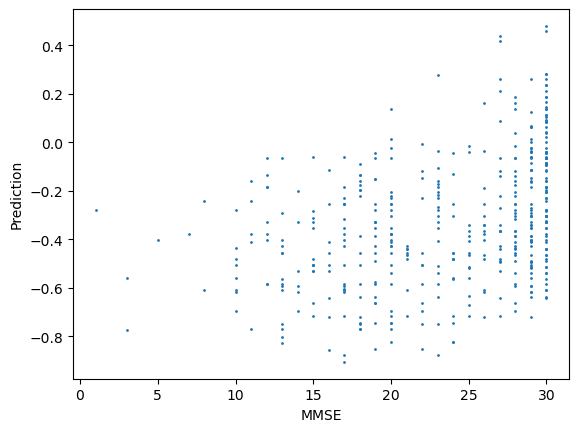

In [11]:
import matplotlib.pyplot as plt

plt.scatter(results['mmse'], results['prediction'], s=1)
plt.xlabel("MMSE")
plt.ylabel("Prediction")

In [12]:
results.to_csv(f"pitt_predictions_{version}_{target}.csv", index=False, sep=";")
